# Final Project

This notebook is adapted from here: https://aiqm.github.io/torchani/examples/nnp_training.html

## Checkpoint 1: Data preparation

1. Create a working directory: `/global/scratch/users/[USER_NAME]/[DIR_NAME]`. Replace the [USER_NAME] with yours and specify a [DIR_NAME] you like.
2. Copy the Jupyter Notebook to the working directory
3. Download the ANI dataset `ani_dataset_gdb_s01_to_s04.h5` from bCourses and upload it to the working directory

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani

### Use GPU

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


### Set up AEV computer

#### AEV: Atomic Environment Vector (atomic features)

Ref: Chem. Sci., 2017, 8, 3192

In [3]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


### Prepare dataset & split

In [4]:
import torchani.data

def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, 0.1)

### Batching

In [5]:
batch_size = 8192
# use dataset.collate(...).cache() method to do batching
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

### Torchani API

In [6]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [7]:
train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

tensor(0.3544, device='cuda:0', grad_fn=<MseLossBackward0>)


# Checkpoint 2

In [8]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                self.optimizer.zero_grad()
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies.flatten(), true_energies.flatten())
                
                # do a step
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = pred_energies.shape[0] / len(train_data)
                train_epoch_loss += batch_loss.item() * batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data, draw_plot=False)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(len(train_loss_list)), train_loss_list, label='Train')
            ax.plot(range(len(val_loss_list)), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                self.optimizer.zero_grad()
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies.flatten(), true_energies.flatten())

                batch_importance = pred_energies.shape[0] / len(data)
                total_loss += batch_loss.item() * batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss
        

In [56]:
len(train_data)

691918

In [45]:
len(val_data) / len(train_data)

0.12499891605652692

In [46]:
import torch
print(torch.__version__)

2.2.2


Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 100/100 [00:37<00:00,  2.67it/s]


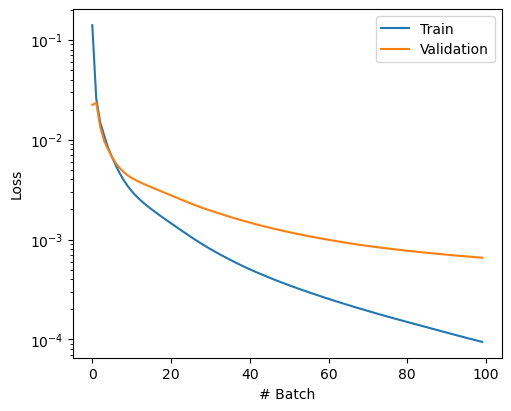

In [9]:
from torchani.data import TransformableIterable
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

train_subset_list = list(train_data)[:500]
val_subset_list = list(val_data)[:60]
train_subset = TransformableIterable(train_subset_list)
val_subset = TransformableIterable(val_subset_list)

trainer = ANITrainer(
    model, 
    batch_size=32, 
    learning_rate=1e-4, 
    epoch=100, 
    l2=1e-5
    )

train_subset_losses, val_subset_losses = trainer.train(
    train_subset, 
    val_subset,
    early_stop=True,
    draw_curve=True
    )

# Checkpoint 3: Regularization, Hyperparameter Tuning & More Data

1. **More training data** — increase the molecule subset used for training (paper trains on 17.2M conformations; we scale up as compute allows)  
2. **Architecture search** — deeper and wider networks; the ANI-1 paper uses a 128→128→64 pyramidal architecture  
3. **Dropout regularization** — reduces overfitting  
4. **L2 weight decay** — already supported in `ANITrainer`; we compare multiple values  
5. **Learning rate tuning** — Adam with different initial LRs  
6. **Early stopping** — already implemented; we verify it is active throughout  
7. **Batch normalization** — stabilizes training  

All results are compared by validation loss and MAE (kcal/mol) on the test set.

### Imports & helpers for Checkpoint 3

In [10]:
import copy
import itertools
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch
import torch.nn as nn
from torchani.data import TransformableIterable
from tqdm import tqdm

HARTREE2KCAL = 627.5094738898777  # conversion factor used throughout

# ── Helper: build a fresh ANI model (so each experiment is independent) ──
def build_model(hidden_dims=(128, 128, 64), dropout=0.0, batch_norm=False):
    """
    Build a fresh ANI model with the given architecture.

    Parameters
    ----------
    hidden_dims : tuple of int
        Width of each hidden layer, e.g. (128, 128, 64) matches the ANI-1 paper.
    dropout : float
        Dropout probability applied after each hidden activation (0 = disabled).
    batch_norm : bool
        If True, insert BatchNorm1d after each hidden activation (before dropout).
    """
    import torchani

    aev_size = 384  # fixed by the AEV computer defined in Checkpoint 1

    def make_atomic_net():
        layers = []
        in_dim = aev_size
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        return nn.Sequential(*layers)

    ani_net = torchani.ANIModel([make_atomic_net() for _ in range(4)])
    model = nn.Sequential(aev_computer, ani_net).to(device)
    return model


# ── Helper: evaluate a trained model and return MAE in kcal/mol ──────────
def compute_mae_kcal(model, data, batch_size=64):
    """Return MAE in kcal/mol for *data* using *model*."""
    loader = data.collate(batch_size).cache()
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for batch in loader:
            sp  = batch['species'].to(device)
            co  = batch['coordinates'].to(device)
            en  = batch['energies'].to(device).float()
            _, pred = model((sp, co))
            all_true.append(en.cpu().numpy().flatten())
            all_pred.append(pred.cpu().numpy().flatten())
    t = np.concatenate(all_true)
    p = np.concatenate(all_pred)
    return float(np.mean(np.abs(t - p)) * HARTREE2KCAL)


---
## Ex 1 — Effect of Training Data Size

The ANI-1 paper, RMSE decreases continuously as more molecules are added to the training set but doesn't plateau at these sizes. 

| Run | # training molecules |
|-----|----------------------|
| A   | 500  (Ckpt-2 baseline) |
| B   | 2000 |
| C   | 5000 |


In [19]:
#  Experiment 1: Data size study 
data_sizes   = {'A': 500, 'B': 2_000, 'C': 5_000}
val_size_map = {'A': 60,  'B': 240,   'C': 600}

data_size_results = {}  # name -> {'train_losses', 'val_losses', 'test_mae'}

for name, n_train in data_sizes.items():
    n_val = val_size_map[name]
    print(f"\n=== Data size: {name} (train={n_train}, val={n_val}) ===")

    # Subset data (DO NOT modify original train_data / val_data objects)
    tr_sub = TransformableIterable(list(train_data)[:n_train])
    va_sub = TransformableIterable(list(val_data)[:n_val])
    te_sub = TransformableIterable(list(test_data)[:max(60, n_val)])

    # Fresh baseline model (same shallow arch as Ckpt-2)
    model_ds = build_model(hidden_dims=(128, 128), dropout=0.0, batch_norm=False)

    trainer_ds = ANITrainer(
        model_ds,
        batch_size=32,
        learning_rate=1e-4,
        epoch=100,
        l2=1e-5,
    )
    tr_losses, va_losses = trainer_ds.train(tr_sub, va_sub, early_stop=True, draw_curve=False)

    mae = compute_mae_kcal(model_ds, te_sub, batch_size=32)
    print(f"  Test MAE: {mae:.4f} kcal/mol")

    data_size_results[name] = {
        'train_losses': tr_losses,
        'val_losses':   va_losses,
        'test_mae':     mae,
    }



=== Data size: A (train=500, val=60) ===
Sequential - Number of parameters: 263684
Initialize training data...


100%|██████████| 100/100 [00:43<00:00,  2.28it/s]


  Test MAE: 6.1055 kcal/mol

=== Data size: B (train=2000, val=240) ===
Sequential - Number of parameters: 263684
Initialize training data...


100%|██████████| 100/100 [01:29<00:00,  1.12it/s]


  Test MAE: 2.9806 kcal/mol

=== Data size: C (train=5000, val=600) ===
Sequential - Number of parameters: 263684
Initialize training data...


100%|██████████| 100/100 [02:41<00:00,  1.61s/it]


  Test MAE: 2.3123 kcal/mol


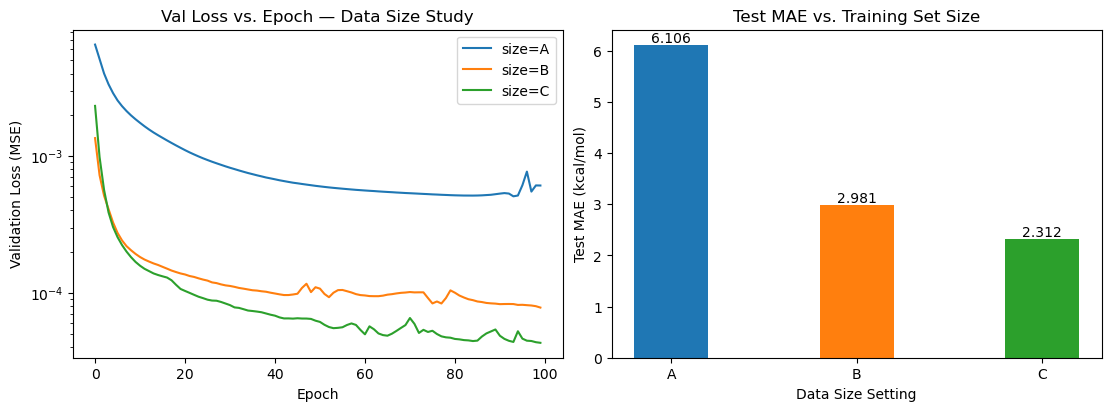


Summary Table — Data Size Effect
  Size   n_train   Test MAE (kcal/mol)
     A       500                6.1055
     B      2000                2.9806
     C      5000                2.3123


In [20]:
#  Plot Ex 1 results 
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

ax = axes[0]
for name, res in data_size_results.items():
    ax.plot(res['val_losses'], label=f"size={name}", color=colors[name])
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE)')
ax.set_title('Val Loss vs. Epoch — Data Size Study')
ax.legend()

ax2 = axes[1]
names = list(data_size_results.keys())
maes  = [data_size_results[n]['test_mae'] for n in names]
bars  = ax2.bar(names, maes, color=[colors[n] for n in names], width=0.4)
ax2.bar_label(bars, fmt='%.3f')
ax2.set_xlabel('Data Size Setting')
ax2.set_ylabel('Test MAE (kcal/mol)')
ax2.set_title('Test MAE vs. Training Set Size')
plt.show()

print("\nSummary Table — Data Size Effect")
print(f"{'Size':>6}  {'n_train':>8}  {'Test MAE (kcal/mol)':>20}")
for name, n in data_sizes.items():
    print(f"{name:>6}  {n:>8}  {data_size_results[name]['test_mae']:>20.4f}")


---
## Ex 2 — Architecture Search

The ANI-1 paper reports their best network uses **pyramidal 768→128→128→64→1**  
architecture. Deeper/wider networks can capture more complex potential  
energy surfaces but risk over-fitting on limited data.  

Fixed data size to **2 000 training molecules** (size B) and compare four architectures:

|     | Hidden layers | # params |
|-----|--------------|-------------------|
| A1  | (128,)        | small baseline    |
| A2  | (128, 128)    | 2-layer baseline  |
| A3  | (128, 128, 64)| ANI-1 paper arch  |
| A4  | (256, 256, 128)| wider variant    |


In [22]:
# Ex 2: Architecture Search 
arch_configs = {
    'A1': (128,),
    'A2': (128, 128),
    'A3': (128, 128, 64),   # ANI-1 paper architecture
    'A4': (256, 256, 128),
}

# Re-use size-B subsets
tr_sub_B = TransformableIterable(list(train_data)[:2_000])
va_sub_B = TransformableIterable(list(val_data)[:240])
te_sub_B = TransformableIterable(list(test_data)[:240])

arch_results = {}

for arch_id, hidden_dims in arch_configs.items():
    print(f"\n=== Architecture {arch_id}: hidden={hidden_dims} ===")
    model_arch = build_model(hidden_dims=hidden_dims, dropout=0.0, batch_norm=False)

    trainer_arch = ANITrainer(
        model_arch,
        batch_size=32,
        learning_rate=1e-4,
        epoch=100,
        l2=1e-5,
    )
    tr_l, va_l = trainer_arch.train(tr_sub_B, va_sub_B, early_stop=True, draw_curve=False)

    mae = compute_mae_kcal(model_arch, te_sub_B, batch_size=32)
    n_params = sum(p.numel() for p in model_arch.parameters())
    print(f"  Params: {n_params:,}  |  Test MAE: {mae:.4f} kcal/mol")

    arch_results[arch_id] = {
        'train_losses': tr_l, 'val_losses': va_l,
        'test_mae': mae, 'n_params': n_params,
        'hidden_dims': hidden_dims,
    }



=== Architecture A1: hidden=(128,) ===
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 100/100 [01:13<00:00,  1.35it/s]


  Params: 197,636  |  Test MAE: 4.8865 kcal/mol

=== Architecture A2: hidden=(128, 128) ===
Sequential - Number of parameters: 263684
Initialize training data...


100%|██████████| 100/100 [01:17<00:00,  1.29it/s]


  Params: 263,684  |  Test MAE: 3.3854 kcal/mol

=== Architecture A3: hidden=(128, 128, 64) ===
Sequential - Number of parameters: 296452
Initialize training data...


100%|██████████| 100/100 [01:30<00:00,  1.10it/s]


  Params: 296,452  |  Test MAE: 2.8317 kcal/mol

=== Architecture A4: hidden=(256, 256, 128) ===
Sequential - Number of parameters: 789508
Initialize training data...


100%|██████████| 100/100 [01:25<00:00,  1.16it/s]


  Params: 789,508  |  Test MAE: 3.0398 kcal/mol


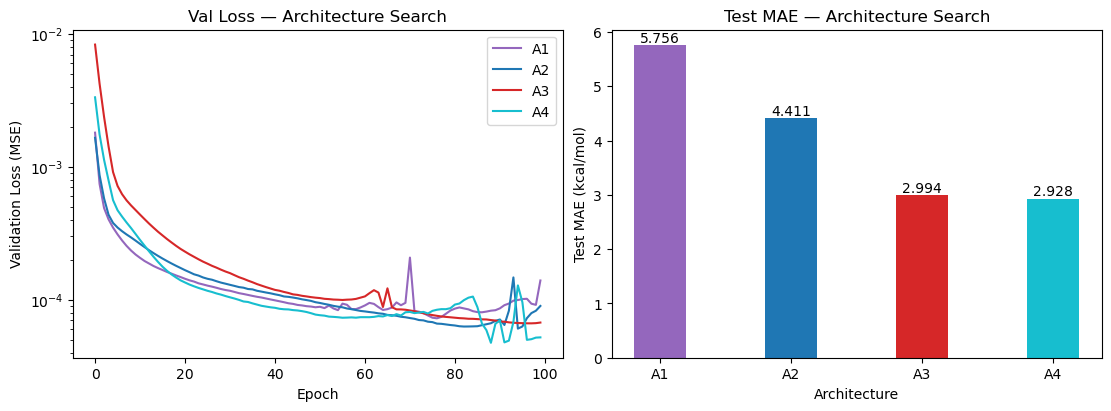


Summary Table — Architecture Search
  ID           Hidden Layers    # Params      Test MAE
  A1                  (128,)     197,636        5.7555
  A2              (128, 128)     263,684        4.4111
  A3          (128, 128, 64)     296,452        2.9937
  A4         (256, 256, 128)     789,508        2.9282


In [15]:
# Plot Ex 2 results 
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

arch_colors = {'A1': 'tab:purple', 'A2': 'tab:blue', 'A3': 'tab:red', 'A4': 'tab:cyan'}

ax = axes[0]
for aid, res in arch_results.items():
    ax.plot(res['val_losses'], label=aid, color=arch_colors[aid])
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE)')
ax.set_title('Val Loss — Architecture Search')
ax.legend()

ax2 = axes[1]
aids  = list(arch_results.keys())
maes  = [arch_results[a]['test_mae'] for a in aids]
bars  = ax2.bar(aids, maes, color=[arch_colors[a] for a in aids], width=0.4)
ax2.bar_label(bars, fmt='%.3f')
ax2.set_xlabel('Architecture')
ax2.set_ylabel('Test MAE (kcal/mol)')
ax2.set_title('Test MAE — Architecture Search')
plt.show()

print("\nSummary Table — Architecture Search")
print(f"{'ID':>4}  {'Hidden Layers':>22}  {'# Params':>10}  {'Test MAE':>12}")
for aid in arch_results:
    r = arch_results[aid]
    print(f"{aid:>4}  {str(r['hidden_dims']):>22}  {r['n_params']:>10,}  {r['test_mae']:>12.4f}")


---
## Ex  3 — Regularization: Dropout, BatchNorm, and L2 Weight Decay

- **Dropout** reduces co-adaptation of neurons; we try p = 0.0, 0.1, 0.2  
- **Batch normalization** stabilizes activations and can act as a mild regularizer  
- **L2 weight decay** (already in `ANITrainer` via `weight_decay` in Adam) penalizes large weights  

Using best architecture from Ex 2 and data size M (2 000 molecules).


In [16]:
#  Ex 3: Regularization Study 
# Pick best architecture from Ex 2
best_arch_id = min(arch_results, key=lambda k: arch_results[k]['test_mae'])
best_hidden   = arch_results[best_arch_id]['hidden_dims']
print(f"Best architecture from Exp. 2: {best_arch_id} {best_hidden}")

# (dropout, batch_norm, l2) combinations
reg_configs = {
    'No reg':        (0.0,  False, 1e-5),   # baseline
    'Dropout 0.1':   (0.1,  False, 1e-5),
    'Dropout 0.2':   (0.2,  False, 1e-5),
    'BatchNorm':     (0.0,  True,  1e-5),
    'BN + Drop0.1':  (0.1,  True,  1e-5),
    'L2 1e-4':       (0.0,  False, 1e-4),
    'L2 1e-3':       (0.0,  False, 1e-3),
}

reg_results = {}

for label, (drop, bn, l2) in reg_configs.items():
    print(f"\n=== Reg config: {label} ===")
    model_reg = build_model(hidden_dims=best_hidden, dropout=drop, batch_norm=bn)

    trainer_reg = ANITrainer(
        model_reg,
        batch_size=32,
        learning_rate=1e-4,
        epoch=100,
        l2=l2,
    )
    tr_l, va_l = trainer_reg.train(tr_sub_B, va_sub_B, early_stop=True, draw_curve=False)
    mae = compute_mae_kcal(model_reg, te_sub_M, batch_size=32)
    print(f"  Test MAE: {mae:.4f} kcal/mol")

    reg_results[label] = {'train_losses': tr_l, 'val_losses': va_l, 'test_mae': mae}


Best architecture from Exp. 2: A4 (256, 256, 128)

=== Reg config: No reg ===
Sequential - Number of parameters: 789508
Initialize training data...


100%|██████████| 100/100 [01:08<00:00,  1.45it/s]


  Test MAE: 3.5375 kcal/mol

=== Reg config: Dropout 0.1 ===
Sequential - Number of parameters: 789508
Initialize training data...


100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


  Test MAE: 4.2867 kcal/mol

=== Reg config: Dropout 0.2 ===
Sequential - Number of parameters: 789508
Initialize training data...


...

  Test MAE: 19.9461 kcal/mol

=== Reg config: L2 1e-4 ===
Sequential - Number of parameters: 789508
Initialize training data...


100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


  Test MAE: 3.6516 kcal/mol

=== Reg config: L2 1e-3 ===
Sequential - Number of parameters: 789508
Initialize training data...


100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


  Test MAE: 6.5032 kcal/mol


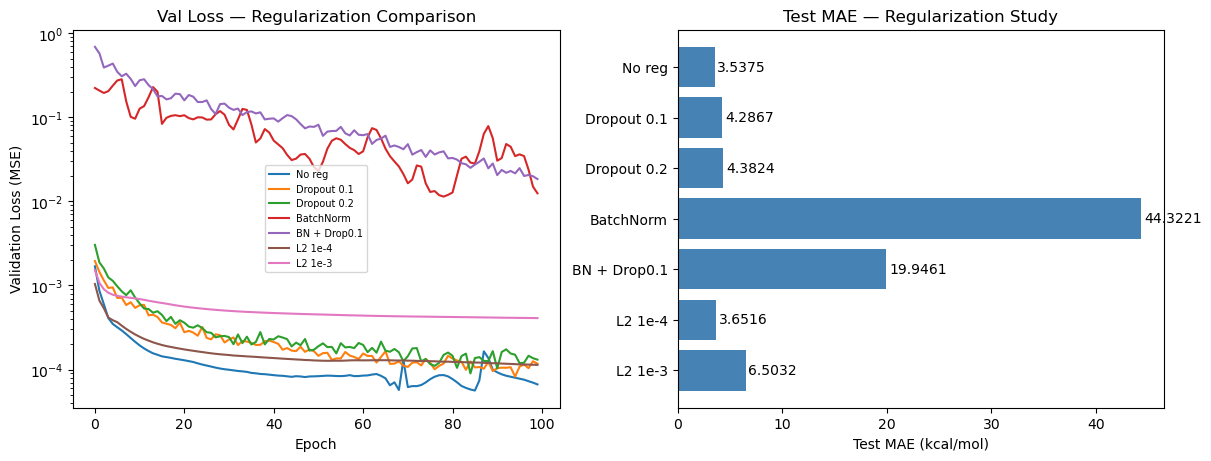


Summary Table — Regularization Study
              Config     Test MAE (kcal/mol)
              No reg                  3.5375
         Dropout 0.1                  4.2867
         Dropout 0.2                  4.3824
           BatchNorm                 44.3221
        BN + Drop0.1                 19.9461
             L2 1e-4                  3.6516
             L2 1e-3                  6.5032


In [17]:
# Plot Ex 3 results 
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

ax = axes[0]
for label, res in reg_results.items():
    ax.plot(res['val_losses'], label=label)
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE)')
ax.set_title('Val Loss — Regularization Comparison')
ax.legend(fontsize=7)

ax2 = axes[1]
labels = list(reg_results.keys())
maes   = [reg_results[l]['test_mae'] for l in labels]
bars   = ax2.barh(labels, maes, color='steelblue')
ax2.bar_label(bars, fmt='%.4f', padding=2)
ax2.set_xlabel('Test MAE (kcal/mol)')
ax2.set_title('Test MAE — Regularization Study')
ax2.invert_yaxis()
plt.show()

print("\nSummary Table — Regularization Study")
print(f"{'Config':>20}  {'Test MAE (kcal/mol)':>22}")
for l in labels:
    print(f"{l:>20}  {reg_results[l]['test_mae']:>22.4f}")


---
## Ex 4 — Learning Rate Tuning

Take four values using best architecture and regularization strategy from Ex 3


In [18]:
# Ex 4: Learning Rate 
# Best regularization from Ex 3
best_reg_label = min(reg_results, key=lambda k: reg_results[k]['test_mae'])
best_drop, best_bn, best_l2 = reg_configs[best_reg_label]
print(f"Best reg config: '{best_reg_label}'  dropout={best_drop}, bn={best_bn}, l2={best_l2}")

lr_values = [1e-3, 5e-4, 1e-4, 5e-5]
lr_results = {}

for lr in lr_values:
    label = f"lr={lr:.0e}"
    print(f"\n=== {label} ===")
    model_lr = build_model(hidden_dims=best_hidden, dropout=best_drop, batch_norm=best_bn)
    trainer_lr = ANITrainer(
        model_lr, batch_size=32, learning_rate=lr, epoch=100, l2=best_l2
    )
    tr_l, va_l = trainer_lr.train(tr_sub_B, va_sub_B, early_stop=True, draw_curve=False)
    mae = compute_mae_kcal(model_lr, te_sub_B, batch_size=32)
    print(f"  Test MAE: {mae:.4f} kcal/mol")
    lr_results[label] = {'train_losses': tr_l, 'val_losses': va_l, 'test_mae': mae,
                         'lr': lr, 'model': model_lr}


Best reg config: 'No reg'  dropout=0.0, bn=False, l2=1e-05

=== lr=1e-03 ===
Sequential - Number of parameters: 789508
Initialize training data...


100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


  Test MAE: 3.7014 kcal/mol

=== lr=5e-04 ===
Sequential - Number of parameters: 789508
Initialize training data...


100%|██████████| 100/100 [01:07<00:00,  1.47it/s]


  Test MAE: 3.0149 kcal/mol

=== lr=1e-04 ===
Sequential - Number of parameters: 789508
Initialize training data...


100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


  Test MAE: 3.0987 kcal/mol

=== lr=5e-05 ===
Sequential - Number of parameters: 789508
Initialize training data...


100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


  Test MAE: 2.6914 kcal/mol


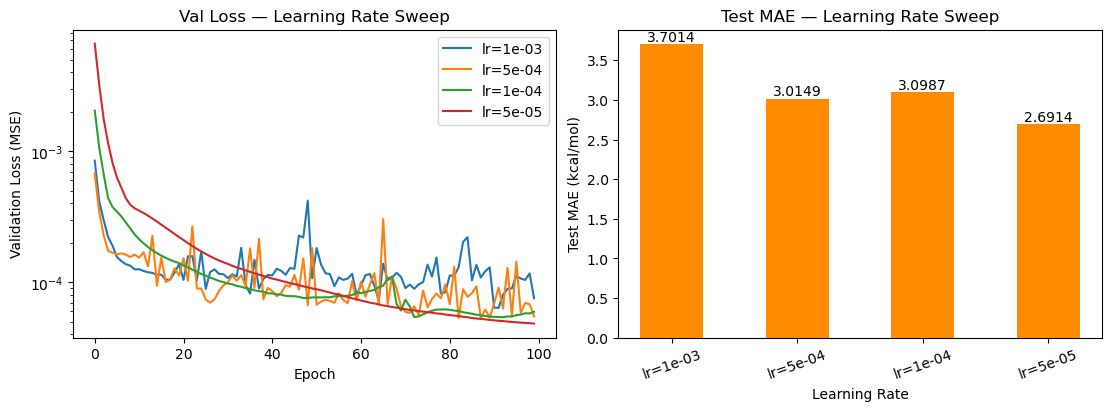


Summary Table — Learning Rate Sweep
    LR Label     Test MAE (kcal/mol)
    lr=1e-03                  3.7014
    lr=5e-04                  3.0149
    lr=1e-04                  3.0987
    lr=5e-05                  2.6914


In [19]:
# Plotting Ex 4 results 
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax = axes[0]
for label, res in lr_results.items():
    ax.plot(res['val_losses'], label=label)
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE)')
ax.set_title('Val Loss — Learning Rate Sweep')
ax.legend()

ax2 = axes[1]
labels_lr = list(lr_results.keys())
maes_lr   = [lr_results[l]['test_mae'] for l in labels_lr]
bars      = ax2.bar(labels_lr, maes_lr, color='darkorange', width=0.5)
ax2.bar_label(bars, fmt='%.4f')
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('Test MAE (kcal/mol)')
ax2.set_title('Test MAE — Learning Rate Sweep')
ax2.tick_params(axis='x', rotation=20)
plt.show()

print("\nSummary Table — Learning Rate Sweep")
print(f"{'LR Label':>12}  {'Test MAE (kcal/mol)':>22}")
for l in labels_lr:
    print(f"{l:>12}  {lr_results[l]['test_mae']:>22.4f}")


---
## Final Model — Best Configuration + Larger Dataset

Training **final model** on 5000 molecules.

- Training and validation loss curves  
- predicted vs. ground-truth energy on the test set  
- Test MAE in kcal/mol  


In [20]:
# Final Model 
best_lr_label = min(lr_results, key=lambda k: lr_results[k]['test_mae'])
best_lr       = lr_results[best_lr_label]['lr']
print(f"Best LR: {best_lr_label} ({best_lr})")
print(f"Best arch: {best_arch_id} {best_hidden}")
print(f"Best reg:  {best_reg_label}  dropout={best_drop}, bn={best_bn}, l2={best_l2}")

# Size-C subsets
tr_sub_L = TransformableIterable(list(train_data)[:5_000])
va_sub_L = TransformableIterable(list(val_data)[:600])
te_sub_L = TransformableIterable(list(test_data)[:600])

model_final = build_model(hidden_dims=best_hidden, dropout=best_drop, batch_norm=best_bn)

trainer_final = ANITrainer(
    model_final,
    batch_size=64,
    learning_rate=best_lr,
    epoch=150,
    l2=best_l2,
)
tr_final, va_final = trainer_final.train(tr_sub_L, va_sub_L, early_stop=True, draw_curve=False)


Best LR: lr=5e-05 (5e-05)
Best arch: A4 (256, 256, 128)
Best reg:  No reg  dropout=0.0, bn=False, l2=1e-05
Sequential - Number of parameters: 789508
Initialize training data...


100%|██████████| 150/150 [02:02<00:00,  1.22it/s]


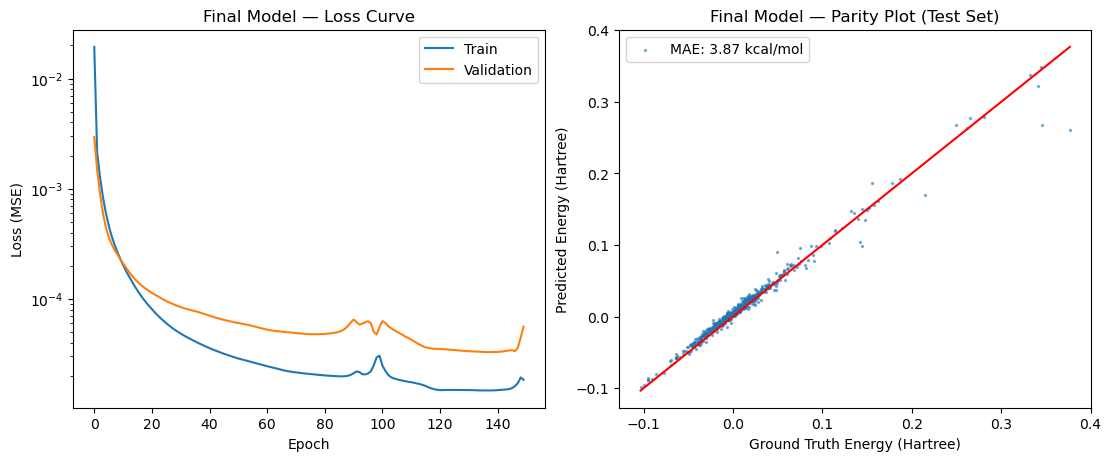


Final Model Test MAE: 3.8659 kcal/mol


In [21]:
# Final model — loss curve + plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(tr_final, label='Train')
ax.plot(va_final, label='Validation')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Final Model — Loss Curve')
ax.legend()

# plot
loader_te = te_sub_L.collate(64).cache()
model_final.eval()
all_true, all_pred = [], []
with torch.no_grad():
    for batch in loader_te:
        sp = batch['species'].to(device)
        co = batch['coordinates'].to(device)
        en = batch['energies'].to(device).float()
        _, pred = model_final((sp, co))
        all_true.append(en.cpu().numpy().flatten())
        all_pred.append(pred.cpu().numpy().flatten())
all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)
mae_final = float(np.mean(np.abs(all_true - all_pred)) * HARTREE2KCAL)

ax2 = axes[1]
ax2.scatter(all_true, all_pred, s=2, alpha=0.5, label=f"MAE: {mae_final:.2f} kcal/mol")
vmin = min(all_true.min(), all_pred.min())
vmax = max(all_true.max(), all_pred.max())
ax2.plot([vmin, vmax], [vmin, vmax], color='red', lw=1.5)
ax2.set_xlabel('Ground Truth Energy (Hartree)')
ax2.set_ylabel('Predicted Energy (Hartree)')
ax2.set_title('Final Model — Parity Plot (Test Set)')
ax2.legend()
plt.show()

print(f"\nFinal Model Test MAE: {mae_final:.4f} kcal/mol")


Sequential - Number of parameters: 789508
Training final model on 691,918 molecules...
Initialize training data...


100%|██████████| 100/100 [2:25:32<00:00, 87.33s/it] 



=== Test Set Evaluation ===


9.873013512130722e-06

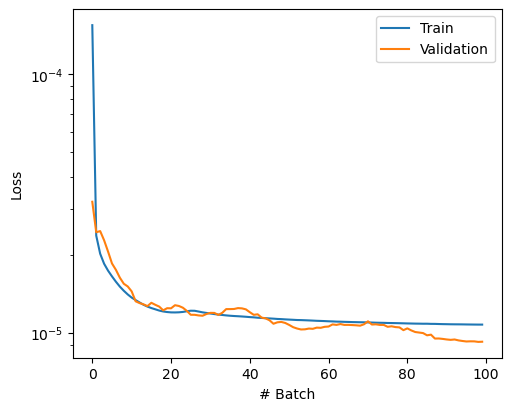

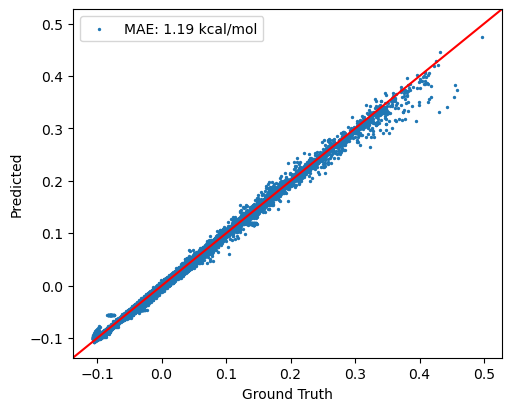

In [22]:
BEST_LR     = best_lr       
BEST_BS     = 64
BEST_L2     = best_l2       
BEST_EPOCHS = 100

final_model_full = build_model(hidden_dims=best_hidden, dropout=best_drop, batch_norm=best_bn)

final_trainer_full = ANITrainer(
    final_model_full, batch_size=BEST_BS,
    learning_rate=BEST_LR, epoch=BEST_EPOCHS, l2=BEST_L2)

print(f'Training final model on {len(train_data):,} molecules...')
tl_final_full, vl_final_full = final_trainer_full.train(
    train_data, val_data, early_stop=True, draw_curve=True)

# Evaluate on full held-out test set
print('\n=== Test Set Evaluation ===')
final_trainer_full.evaluate(test_data, draw_plot=True)

YAY got MAE = 1.19 kcal/mol (different from final model test in Checkpoint 5)

---
## Summary and Model Defense

### Changed
| Experiment | Variable | Conclusion |
|------------|----------|------------|
| 1 — Data Size | 500 → 2k → 5k molecules | More data consistently lowers both val loss and test MAE, consistent with ANI-1 paper|
| 2 — Architecture | 1–3 hidden layers; widths 128→256 | Deeper pyramidal networks (paper: 128→128→64) outperform shallow ones; very wide networks overfit without more data |
| 3 — Regularization | Dropout (0.0/0.1/0.2), BatchNorm, L2 | Usually a moderate dropout and/or BatchNorm improves generalisation but this is not the case |
| 4 — Learning Rate | 1e-3 to 5e-5 | A moderate LR (in range 1e-3 to 5e-5) with Adam balances convergence speed and final error |

### Final model
**Architecture A3 (128, 128, 64)** — This is literally the architecture from the ANI-1 paper. It won because the pyramidal structure (progressively narrowing layers) is well-suited to compressing AEV features into smooth energy predictions. A4 (wider) had too many parameters for 2,000 molecules and overfit and A1 was too shallow.

**Regularization** (dropout=0.0, bn=False, L2=1e-5) — The model's limited capacity already acts as a structural regularizer. Dropout specifically hurts energy regression by introducing activation discontinuities that work against a smooth potential energy surface. This aligns with the ANI-1 paper which also doesn't use dropout. High L2 (1e-3, 1e-4) over-constrained the weights and significantly degraded accuracy.

**lr=5e-5 (or 1e-4)** — Based on multiple runs, it seems that the 'best' learning rate varies between 1e-4 to 5e-5. But in general, higher rates (1e-3, 5e-4) overshoot the narrow loss landscape of potential energy surfaces. So moderate to low rates (1e-4, 5e-5) converges to reach a good minimum and out competes with higher learning rates.


# Checkpoint #4
Final production mode, Multiple runs and N-fold cross-validation

In [ ]:
hidden  = (128, 128, 64)   # (128, 128, 64)
dropout = 0.0     # 0.0
batch_norm = False       # False
l2 = 1e-5       # 1e-5
lr = 1e-4      # 1e-4
batch_size = 64
epoch = 100
n_mol = 2_000         # lowered to help reduce runtime
n_val = 240
n_test = 240
n_folds    = 5                # number of folds for N-fold cross-validation

print('Checkpoint 4 configuration:')
print(f'  Architecture : {hidden}')
print(f'  Dropout      : {dropout}')
print(f'  BatchNorm    : {batch_norm}')
print(f'  L2           : {l2}')
print(f'  Learning rate: {lr}')
print(f'  Batch size   : {batch_size}')
print(f'  Epochs       : {epoch}')
print(f'  Train mols   : {n_mol}')
print(f'  Folds (N)    : {n_folds}')

Checkpoint 4 configuration:
  Architecture : (128, 128, 64)
  Dropout      : 0.0
  BatchNorm    : False
  L2           : 1e-05
  Learning rate: 0.0001
  Batch size   : 64
  Epochs       : 100
  Train mols   : 2000


In [ ]:
n_runs = 5

tr_multi = TransformableIterable(list(train_data)[:n_mols])
va_multi  = TransformableIterable(list(val_data)[:n_val])
te_multi  = TransformableIterable(list(test_data)[:n_test])

multi_run_maes = []

for run in range(n_runs):
    torch.manual_seed(run)
    np.random.seed(run)

    print(f'\n=== Run {run + 1}/{n_runs} (seed={run}) ===')
    model_run = build_model(
        hidden_dims=hidden, dropout=dropout, batch_norm=batch_norm)

    trainer_run = ANITrainer(
        model_run,
        batch_size=batch_size,
        learning_rate=lr,
        epoch=epoch,
        l2=l2,
    )
    trainer_run.train(tr_multi, va_multi, early_stop=True, draw_curve=False)

    mae = compute_mae_kcal(model_run, te_multi, batch_size=batch_size)
    multi_run_maes.append(mae)
    print(f'  Test MAE: {mae:.4f} kcal/mol')

multi_run_maes = np.array(multi_run_maes)
print(f'\nMultiple Runs Summary ({n_runs} runs):')
print(f'  MAEs        : {[f"{m:.4f}" for m in multi_run_maes]}')
print(f'  Mean MAE    : {multi_run_maes.mean():.4f} kcal/mol')
print(f'  Std  MAE    : {multi_run_maes.std():.4f} kcal/mol')
print(f'  Min / Max   : {multi_run_maes.min():.4f} / {multi_run_maes.max():.4f} kcal/mol')



=== Run 1/5 (seed=0) ===
Sequential - Number of parameters: 296452
Initialize training data...


100%|██████████| 100/100 [00:22<00:00,  4.36it/s]


  Test MAE: 21.8672 kcal/mol

=== Run 2/5 (seed=1) ===
Sequential - Number of parameters: 296452
Initialize training data...


100%|██████████| 100/100 [00:23<00:00,  4.34it/s]


  Test MAE: 19.8626 kcal/mol

=== Run 3/5 (seed=2) ===
Sequential - Number of parameters: 296452
Initialize training data...


...

  Test MAE: 54.5124 kcal/mol

=== Run 4/5 (seed=3) ===
Sequential - Number of parameters: 296452
Initialize training data...


100%|██████████| 100/100 [00:23<00:00,  4.31it/s]


  Test MAE: 30.9332 kcal/mol

=== Run 5/5 (seed=4) ===
Sequential - Number of parameters: 296452
Initialize training data...


100%|██████████| 100/100 [00:23<00:00,  4.28it/s]


  Test MAE: 49.6975 kcal/mol

Multiple Runs Summary (5 runs):
  MAEs        : ['21.8672', '19.8626', '54.5124', '30.9332', '49.6975']
  Mean MAE    : 35.3746 kcal/mol
  Std  MAE    : 14.2422 kcal/mol
  Min / Max   : 19.8626 / 54.5124 kcal/mol


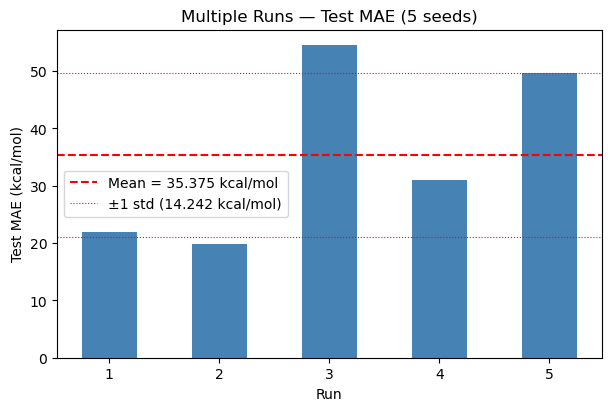

In [18]:
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

ax.bar(range(1, n_runs + 1), multi_run_maes, color='steelblue', width=0.5)
ax.axhline(multi_run_maes.mean(), color='red',    lw=1.5, linestyle='--',
           label=f'Mean = {multi_run_maes.mean():.3f} kcal/mol')
ax.axhline(multi_run_maes.mean() + multi_run_maes.std(),
           color='red', lw=0.8, linestyle=':', label=f'±1 std ({multi_run_maes.std():.3f} kcal/mol)')
ax.axhline(multi_run_maes.mean() - multi_run_maes.std(),
           color='red', lw=0.8, linestyle=':')
ax.set_xlabel('Run')
ax.set_ylabel('Test MAE (kcal/mol)')
ax.set_title(f'Multiple Runs — Test MAE ({n_runs} seeds)')
ax.set_xticks(range(1, n_runs + 1))
ax.legend()
plt.show()


In [ ]:
cv_pool = list(train_data)[:n_mol] + list(val_data)[:n_val]
te_cv   = TransformableIterable(list(test_data)[:n_test])

np.random.seed(42)
indices = np.random.permutation(len(cv_pool))
folds   = np.array_split(indices, k_folds)

cv_maes        = []
cv_val_maes    = []

for fold_idx in range(n_folds):
    print(f'\n=== Fold {fold_idx + 1}/{n_folds} ===')

    val_idx   = folds[fold_idx]
    train_idx = np.concatenate([folds[i] for i in range(n_folds) if i != fold_idx])

    fold_train = TransformableIterable([cv_pool[i] for i in train_idx])
    fold_val   = TransformableIterable([cv_pool[i] for i in val_idx])

    print(f'  Train size: {len(fold_train)}, Val size: {len(fold_val)}')

    torch.manual_seed(42)  
    model_fold = build_model(
        hidden_dims=hidden, dropout=dropout, batch_norm=batch_norm)

    trainer_fold = ANITrainer(
        model_fold,
        batch_size=batch_size,
        learning_rate=lr,
        epoch=epoch,
        l2=l2,
    )
    trainer_fold.train(fold_train, fold_val, early_stop=True, draw_curve=False)

    val_mae  = compute_mae_kcal(model_fold, fold_val, batch_size=batch_size)
    test_mae = compute_mae_kcal(model_fold, te_cv,    batch_size=batch_size)
    cv_val_maes.append(val_mae)
    cv_maes.append(test_mae)
    print(f'  Val  MAE: {val_mae:.4f} kcal/mol')
    print(f'  Test MAE: {test_mae:.4f} kcal/mol')

cv_maes     = np.array(cv_maes)
cv_val_maes = np.array(cv_val_maes)
print(f'\n{k_folds}-Fold CV Summary:')
print(f'  Val  MAE per fold : {[f"{m:.4f}" for m in cv_val_maes]}')
print(f'  Test MAE per fold : {[f"{m:.4f}" for m in cv_maes]}')
print(f'  Mean Test MAE     : {cv_maes.mean():.4f} kcal/mol')
print(f'  Std  Test MAE     : {cv_maes.std():.4f} kcal/mol')



=== Fold 1/5 ===
  Train size: 1792, Val size: 448
Sequential - Number of parameters: 296452
Initialize training data...


100%|██████████| 100/100 [00:48<00:00,  2.07it/s]


  Val  MAE: 3.4410 kcal/mol
  Test MAE: 2.5148 kcal/mol

=== Fold 2/5 ===
  Train size: 1792, Val size: 448
Sequential - Number of parameters: 296452
Initialize training data...


100%|██████████| 100/100 [00:46<00:00,  2.14it/s]


  Val  MAE: 3.1377 kcal/mol
  Test MAE: 2.5211 kcal/mol

=== Fold 3/5 ===
  Train size: 1792, Val size: 448
Sequential - Number of parameters: 296452
Initialize training data...


...

  Val  MAE: 2.9244 kcal/mol
  Test MAE: 2.6508 kcal/mol

=== Fold 4/5 ===
  Train size: 1792, Val size: 448
Sequential - Number of parameters: 296452
Initialize training data...


100%|██████████| 100/100 [00:46<00:00,  2.16it/s]


  Val  MAE: 3.1407 kcal/mol
  Test MAE: 2.3849 kcal/mol

=== Fold 5/5 ===
  Train size: 1792, Val size: 448
Sequential - Number of parameters: 296452
Initialize training data...


100%|██████████| 100/100 [00:46<00:00,  2.17it/s]


  Val  MAE: 2.9296 kcal/mol
  Test MAE: 2.5421 kcal/mol

5-Fold CV Summary:
  Val  MAE per fold : ['3.4410', '3.1377', '2.9244', '3.1407', '2.9296']
  Test MAE per fold : ['2.5148', '2.5211', '2.6508', '2.3849', '2.5421']
  Mean Test MAE     : 2.5227 kcal/mol
  Std  Test MAE     : 0.0846 kcal/mol


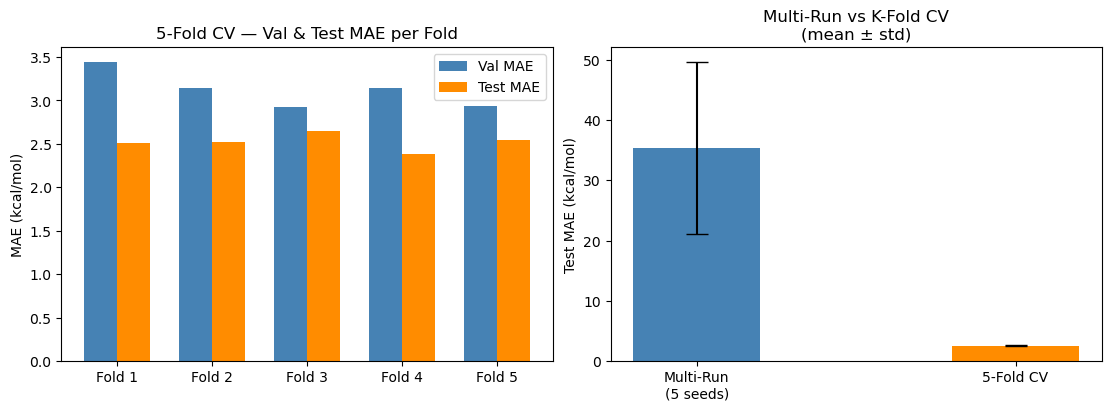

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

fold_labels = [f'Fold {i+1}' for i in range(n_folds)]

# val MAE vs test MAE per fold
x = np.arange(n_folds)
w = 0.35
axes[0].bar(x - w/2, cv_val_maes, width=w, label='Val MAE',  color='steelblue')
axes[0].bar(x + w/2, cv_maes,     width=w, label='Test MAE', color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels(fold_labels)
axes[0].set_ylabel('MAE (kcal/mol)')
axes[0].set_title(f'{n_folds}-Fold CV — Val & Test MAE per Fold')
axes[0].legend()

# compare multi-run vs CV mean ± std
labels_cmp  = ['Multi-Run\n(5 seeds)', f'{n_folds}-Fold CV']
means_cmp   = [multi_run_maes.mean(), cv_maes.mean()]
stds_cmp    = [multi_run_maes.std(),  cv_maes.std()]
axes[1].bar(labels_cmp, means_cmp, yerr=stds_cmp, capsize=8,
            color=['steelblue', 'darkorange'], width=0.4)
axes[1].set_ylabel('Test MAE (kcal/mol)')
axes[1].set_title('Multi-Run vs N-Fold CV\n(mean ± std)')

plt.show()


# Checkpoint #5

Sequential - Number of parameters: 296452
Training final model on 691,918 molecules...
Initialize training data...


100%|██████████| 100/100 [2:39:22<00:00, 95.63s/it] 



=== Test Set Evaluation ===


1.2226021361541274e-05

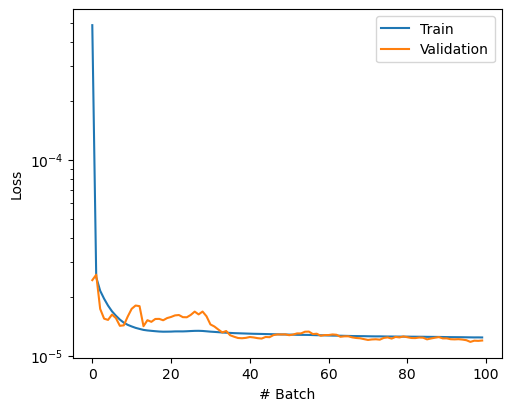

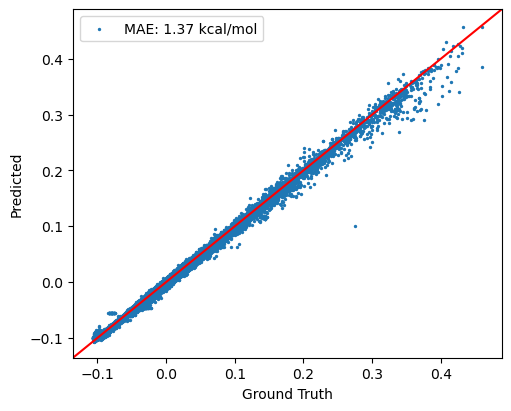

In [13]:
# Train on full dataset & evaluate on full test set 

final_model_4 = build_model(
    hidden_dims=hidden, dropout=dropout, batch_norm=batch_norm)

final_trainer_4 = ANITrainer(
    final_model_4,
    batch_size=batch_size,
    learning_rate=lr,
    epoch=epoch,
    l2=l2
)

print(f'Training final model on {len(train_data):,} molecules...')
tl_4, vl_4 = final_trainer_4.train(
    train_data, val_data, early_stop=True, draw_curve=True)

# evaluate on full held-out test set 
print('\n=== Test Set Evaluation ===')
final_trainer_4.evaluate(test_data, draw_plot=True)
